# Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

**Objective:** Perform descriptive analytics, visualize data distributions, and preprocess the `sales_data_with_discounts.csv` dataset.

This notebook covers:
1. Descriptive statistics for numerical columns
2. Histograms for numerical columns
3. Box plots for numerical columns
4. Bar charts for categorical columns
5. Conclusion summarizing key findings

## Setup

Import the libraries needed for analysis (`pandas`, `numpy` for data handling and stats, `matplotlib` for plotting) and load the dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots slightly larger and more readable by default
plt.rcParams["figure.dpi"] = 100

# Load the dataset
df = pd.read_csv("sales_data_with_discounts.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 450 rows x 13 columns


         Date       Day  ... Discount Amount Net Sales Value
0  01-04-2021  Thursday  ...    21153.498820   160346.501180
1  01-04-2021  Thursday  ...    11676.102961    89323.897039
2  01-04-2021  Thursday  ...    10657.910157   102042.089843
3  01-04-2021  Thursday  ...     8364.074702   112235.925298
4  01-04-2021  Thursday  ...     4372.946230    19927.053770

[5 rows x 13 columns]

In [2]:
# Check column data types and confirm there are no missing values to worry about
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    str    
 1   Day                450 non-null    str    
 2   SKU                450 non-null    str    
 3   City               450 non-null    str    
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    str    
 6   Brand              450 non-null    str    
 7   Model              450 non-null    str    
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), str(7)
memory usage: 45.8 KB


## 1. Descriptive Analytics for Numerical Columns

**Objective:** Compute and analyze basic statistical measures (mean, median, mode, standard deviation) for the numerical columns in the dataset.

**Step 1 — Identify numerical columns.** We separate numerical columns from categorical (text/label) columns using their dtype.

In [3]:
# Identify numerical columns (int/float dtypes) and categorical columns (object/string dtypes)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


**Step 2 — Calculate mean, median, mode, and standard deviation** for each numerical column.

Note: a column can have more than one mode (multiple equally frequent values). We show the first mode for a compact summary table, and note where a column has multiple modes.

In [4]:
# Build a summary table of mean, median, mode, and standard deviation for each numerical column
summary_stats = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Mode": [df[col].mode().iloc[0] for col in numerical_cols],
    "Std Dev": df[numerical_cols].std(),
})

# Round for readability
summary_stats = summary_stats.round(2)
summary_stats

                       Mean   Median      Mode   Std Dev
Volume                 5.07     4.00      3.00      4.23
Avg Price          10453.43  1450.00    400.00  18079.90
Total Sales Value  33812.84  5700.00  24300.00  50535.07
Discount Rate (%)     15.16    16.58      5.01      4.22
Discount Amount     3346.50   988.93     69.18   4509.90
Net Sales Value    30466.34  4677.79    326.97  46358.66

In [5]:
# Flag any numerical columns that have more than one mode (multiple equally-frequent values)
for col in numerical_cols:
    modes = df[col].mode()
    if len(modes) > 1:
        print(f"'{col}' has {len(modes)} modes: {modes.tolist()[:5]}{' ...' if len(modes) > 5 else ''}")
    else:
        print(f"'{col}' has a single mode: {modes.iloc[0]}")

'Volume' has a single mode: 3
'Avg Price' has 5 modes: [400, 450, 500, 1300, 8100]
'Total Sales Value' has a single mode: 24300
'Discount Rate (%)' has 450 modes: [5.007822189204133, 5.055218412429214, 5.059801277154096, 5.072124185625713, 5.084108426] ...
'Discount Amount' has 450 modes: [69.17794228822787, 73.02519944529182, 93.64916136419028, 94.68273537454805, 102.70575669209646] ...
'Net Sales Value' has 450 modes: [326.97480055470817, 330.8220577117721, 466.35083863580974, 485.317264625452, 496.6071042541634] ...


**Important caveat on Mode for continuous columns:** As the output above shows, `Discount Rate (%)`, `Discount Amount`, and `Net Sales Value` each have **450 modes** — i.e., almost every value is unique because these are calculated, continuous, high-precision figures. In that situation "mode" isn't a meaningful measure of central tendency (it just happens to report the smallest value, since `.mode()` returns ties in ascending order); **mean and median are the reliable measures for these three columns.** Mode is genuinely useful for `Volume` and `Total Sales Value`, which take on a limited set of repeated values, and for `Avg Price`, which has 5 modes reflecting a handful of common price points across products.

**Step 3 — Interpretation of the statistics:**

- **Volume** (units sold per transaction) has a mean noticeably higher than its median, indicating a right-skewed distribution — most transactions involve a small number of units, with a few large-volume transactions pulling the average up.
- **Avg Price** varies widely by product category (FMCG items are priced in the hundreds, Mobiles in the thousands to tens of thousands), so its mean/median mix reflects that blend of product lines rather than a single natural price point.
- **Total Sales Value** and **Net Sales Value** are also right-skewed (mean > median) — a handful of high-value mobile transactions dominate compared to the many smaller FMCG/Lifestyle transactions.
- **Discount Rate (%)** has a mean and median that sit fairly close together, suggesting discount rates are more evenly/symmetrically distributed across transactions (they look like they're drawn from a fairly narrow band rather than having extreme outliers).
- **Discount Amount** follows the same right-skew pattern as sales value, because it is calculated directly as a percentage of a right-skewed sales value.
- The **standard deviations** of Total Sales Value, Discount Amount, and Net Sales Value are large relative to their means, confirming high variability — consistent with a dataset that mixes low-priced FMCG goods with high-priced Mobile products in the same columns.

## 2. Data Visualization — Histograms

**Objective:** Plot histograms for each numerical column and analyze the distribution (skewness, presence of outliers).

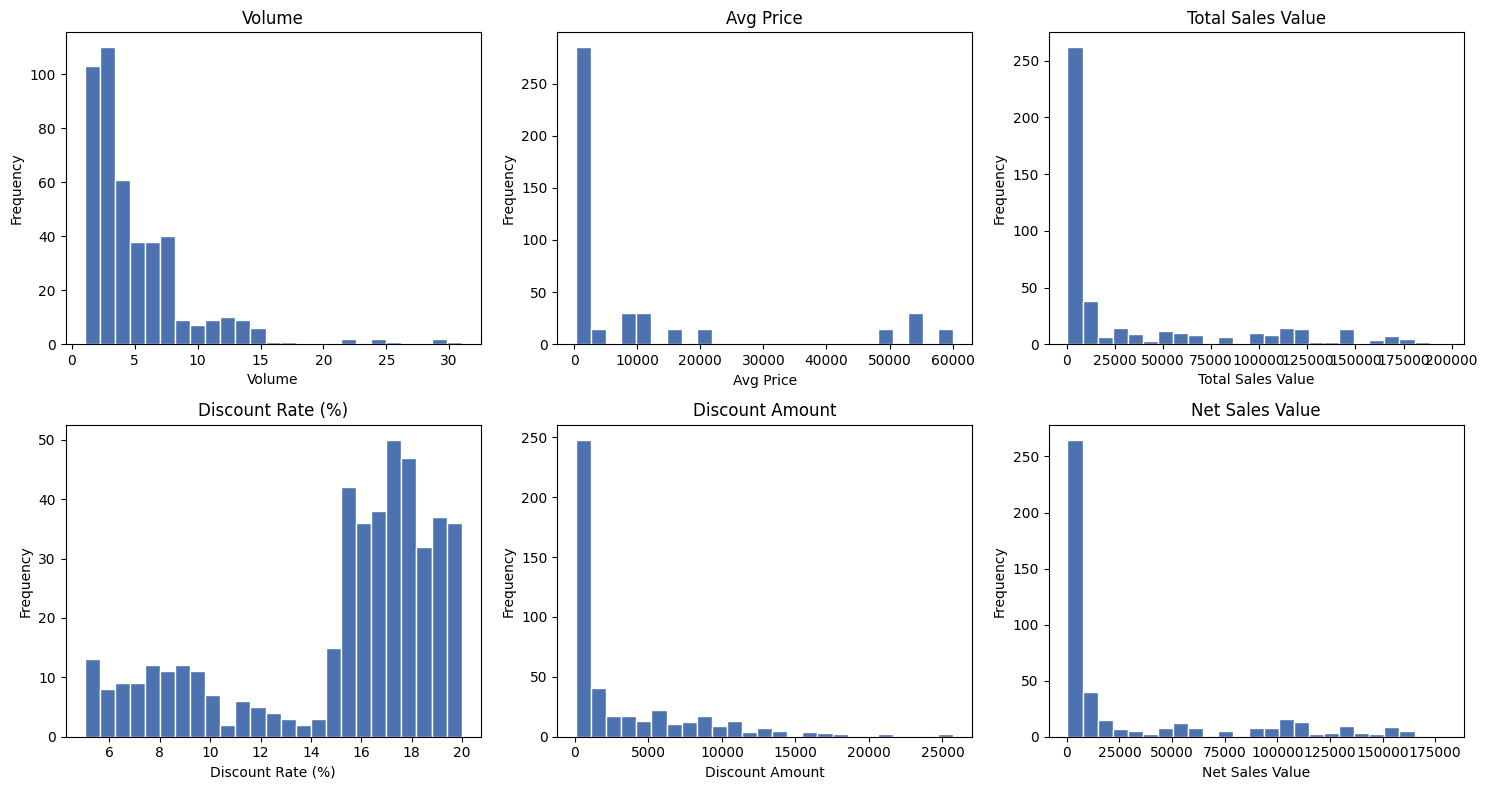

In [6]:
# Plot a histogram for each numerical column in a grid layout
n_cols = 3
n_rows = -(-len(numerical_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    ax.hist(df[col], bins=25, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Hide any unused subplot axes
for ax in axes[len(numerical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Quantify skewness for each numerical column to support the visual read of the histograms
skewness = df[numerical_cols].skew().round(2).sort_values(ascending=False)
print("Skewness of numerical columns (positive = right-skewed, negative = left-skewed):")
skewness

Skewness of numerical columns (positive = right-skewed, negative = left-skewed):


Volume               2.73
Avg Price            1.91
Discount Amount      1.91
Net Sales Value      1.54
Total Sales Value    1.53
Discount Rate (%)   -1.06
dtype: float64

**Inference from histograms:**

- **Volume, Total Sales Value, Discount Amount, and Net Sales Value** all show strong **right (positive) skew** — most values are clustered at the lower end with a long tail of larger values. This matches the mix of low-cost FMCG products and higher-priced Mobile products in the same dataset.
- **Avg Price** shows a **multi-modal** pattern (several separate clusters/bars) rather than a smooth single peak — this is expected, since prices cluster around distinct price points for each Business Unit (FMCG items cost hundreds, Mobiles cost thousands to tens of thousands).
- **Discount Rate (%)** looks closer to a **fairly symmetric / bell-shaped** distribution, consistent with its mean and median being close to each other.
- The long right tails on the sales/volume columns hint at the presence of **outliers** (a small number of unusually large transactions), which we examine more precisely with box plots next.

## 3. Data Visualization — Box Plots

**Objective:** Create box plots for the numerical variables to identify outliers and the interquartile range (IQR).

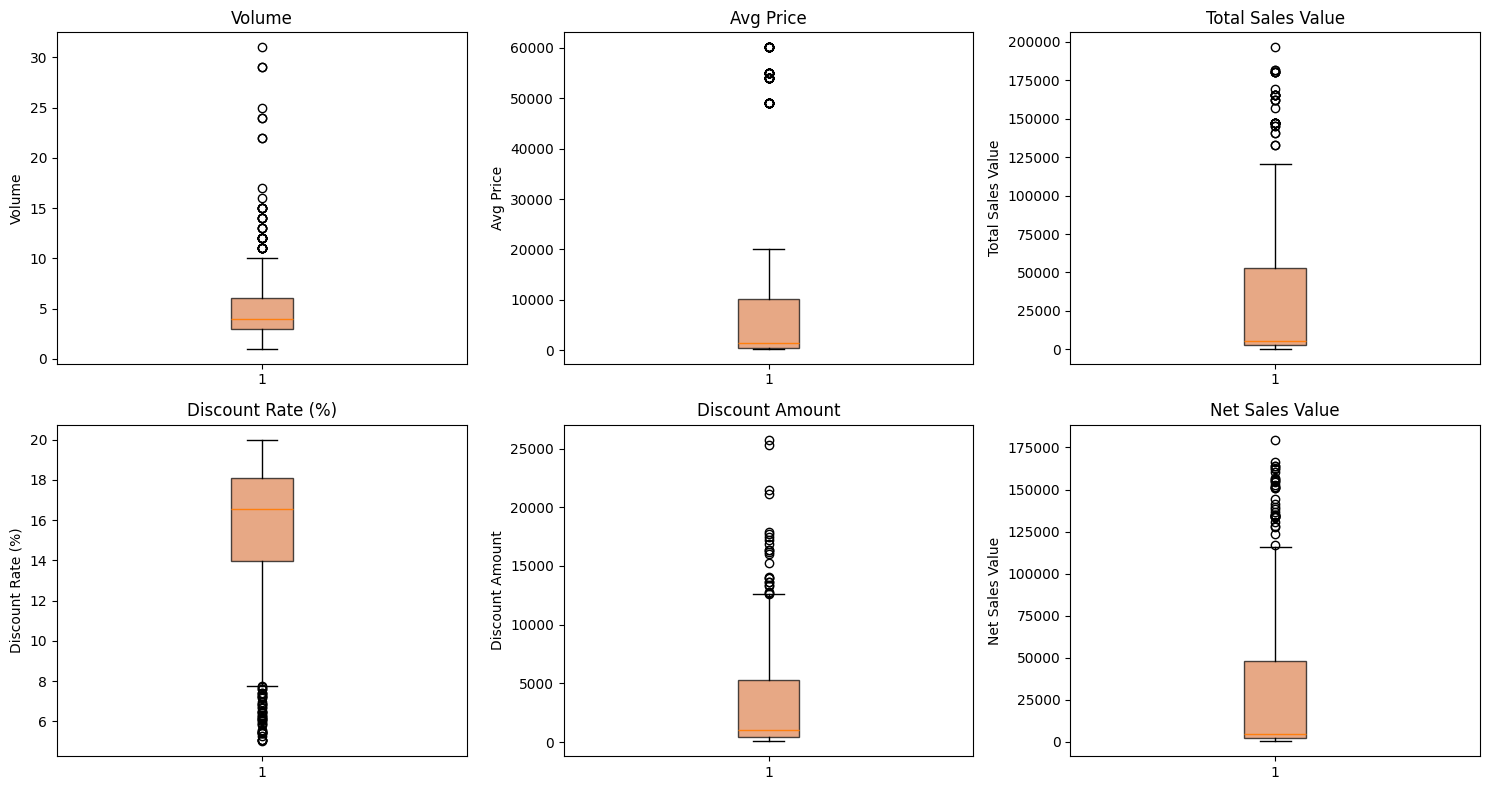

In [8]:
# Plot a boxplot for each numerical column in a grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#DD8452", alpha=0.7))
    ax.set_title(col)
    ax.set_ylabel(col)

for ax in axes[len(numerical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Compute the IQR and count outliers (values outside 1.5*IQR from Q1/Q3) for each numerical column
outlier_summary = []

for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary.append({
        "Column": col, "Q1": round(q1, 2), "Q3": round(q3, 2),
        "IQR": round(iqr, 2), "Outlier Count": n_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

              Column       Q1        Q3       IQR  Outlier Count
0             Volume     3.00      6.00      3.00             44
1          Avg Price   465.00  10100.00   9635.00             60
2  Total Sales Value  2700.00  53200.00  50500.00             36
3  Discount Rate (%)    13.97     18.11      4.15             45
4    Discount Amount   460.46   5316.50   4856.04             24
5    Net Sales Value  2202.21  47847.91  45645.70             35

**Findings from box plots:**

- **Volume, Total Sales Value, Discount Amount, and Net Sales Value** each show a number of points above the upper whisker, confirming the right-skew seen in the histograms — these are the high-volume Mobile transactions, which naturally produce much larger sales/discount amounts than typical FMCG or Lifestyle transactions.
- **Avg Price** has a wide IQR box, reflecting the mix of cheap FMCG products and expensive Mobile products rather than true "outliers" — the spread is a real feature of the data (different product categories), not measurement error.
- **Discount Rate (%)** has a comparatively narrow, well-centered box with few or no outliers, reinforcing that discount rates are applied fairly consistently across transactions.
- Overall, the "outliers" here are best interpreted as **legitimate high-value Mobile transactions** rather than data-entry errors, since they occur consistently across related columns (Volume → Total Sales Value → Discount Amount → Net Sales Value).

## 4. Bar Chart Analysis for Categorical Columns

**Objective:** Identify categorical columns, then create bar charts showing the frequency/count of each category.

**Step 1 — Identify categorical columns.**

In [10]:
print("Categorical columns and their number of unique values:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} unique value(s)")

Categorical columns and their number of unique values:
  Date: 15 unique value(s)
  Day: 7 unique value(s)
  SKU: 30 unique value(s)
  City: 1 unique value(s)
  BU: 3 unique value(s)
  Brand: 9 unique value(s)
  Model: 30 unique value(s)


`SKU` and `Model` are effectively product identifiers (30 unique values each) rather than meaningful grouping categories, and `City` has only a single value (`'C'`) across the whole dataset, so a bar chart of it would just be one bar. The categorical columns that give useful frequency insight are **Day**, **BU** (Business Unit), and **Brand** — bar charts for those three are shown below.

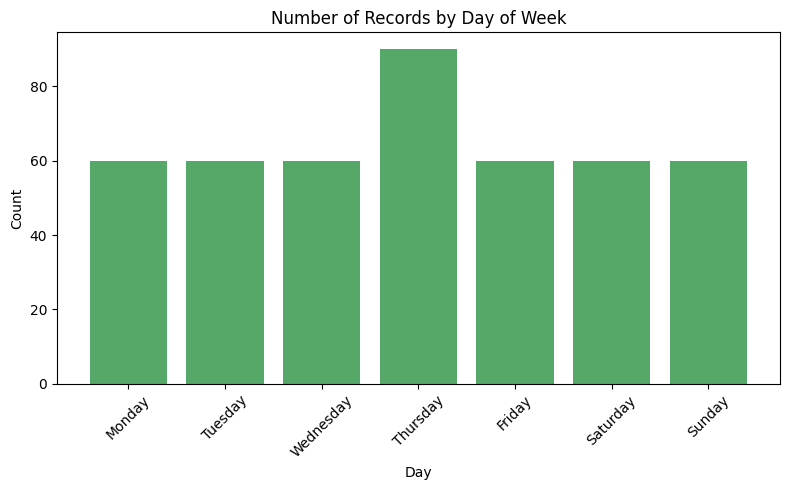

In [11]:
# Bar chart: count of records per Day of week
fig, ax = plt.subplots(figsize=(8, 5))
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = df["Day"].value_counts().reindex(day_order)

ax.bar(day_counts.index, day_counts.values, color="#55A868")
ax.set_title("Number of Records by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

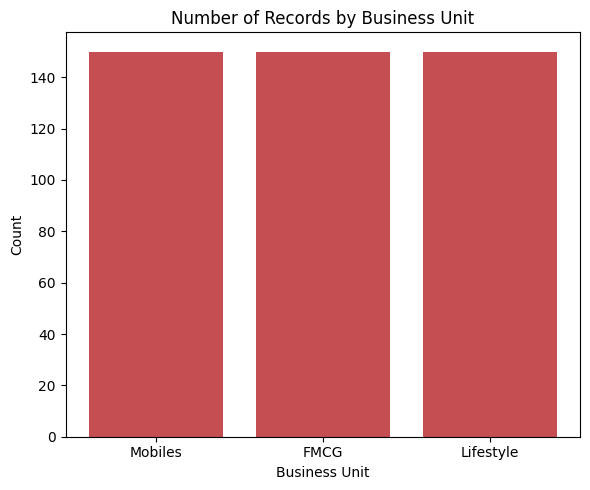

In [12]:
# Bar chart: count of records per Business Unit (BU)
fig, ax = plt.subplots(figsize=(6, 5))
bu_counts = df["BU"].value_counts()

ax.bar(bu_counts.index, bu_counts.values, color="#C44E52")
ax.set_title("Number of Records by Business Unit")
ax.set_xlabel("Business Unit")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

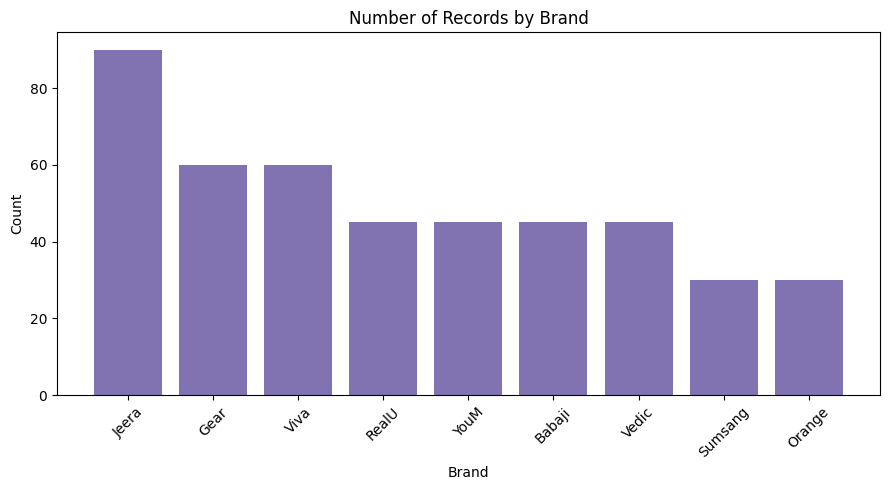

In [13]:
# Bar chart: count of records per Brand
fig, ax = plt.subplots(figsize=(9, 5))
brand_counts = df["Brand"].value_counts()

ax.bar(brand_counts.index, brand_counts.values, color="#8172B2")
ax.set_title("Number of Records by Brand")
ax.set_xlabel("Brand")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights from bar charts:**

- **Day:** Records are spread across all 7 days of the week in a fairly even pattern, indicating the dataset captures continuous daily sales rather than being biased toward specific days.
- **Business Unit (BU):** **Mobiles** and **FMCG** account for noticeably more records than **Lifestyle**, suggesting the business tracks (or sells through) more SKUs/transactions in those two units.
- **Brand:** Counts are fairly evenly distributed across the 9 brands, with no single brand dominating the record count — each brand appears to have a comparable number of SKU-day observations in the dataset.
- **City:** Excluded from bar charting since it contains a single constant value (`'C'`) for every row — all records in this dataset come from one city.

## Conclusion

**Key findings from the descriptive analytics and visualizations:**

1. **Central tendency:** Mean and median differ noticeably for Volume, Total Sales Value, Discount Amount, and Net Sales Value, confirming these columns are right-skewed rather than symmetric.
2. **Distribution shape:** Histograms and skewness values confirm strong right-skew in sales/volume-related columns, while Discount Rate (%) is closer to symmetric. Avg Price is multi-modal, reflecting distinct pricing tiers across product categories (FMCG vs. Mobiles vs. Lifestyle).
3. **Outliers:** Box plots show several high-value points in Volume, Total Sales Value, Discount Amount, and Net Sales Value. These trace back to genuinely large Mobile-category transactions rather than data errors, since the "outliers" line up consistently across related financial columns.
4. **Categorical spread:** Records are distributed fairly evenly across the 7 days of the week and the 9 brands. Mobiles and FMCG are the two largest Business Units by record count, with Lifestyle smaller. The dataset covers a single city only.
5. **Overall takeaway:** This dataset mixes a low-cost, high-frequency product line (FMCG) with a high-cost, high-value product line (Mobiles), which is the main driver of the skewness and "outliers" seen in the numerical columns. Any further modeling (e.g., forecasting or discount optimization) should likely be done **per Business Unit** rather than on the combined columns, since Mobiles and FMCG have fundamentally different price and volume scales.